# Baseline Stratified K-Fold Cross-Validation
XLM-RoBERTa large with the fixed hyperparameters found via Optuna HPO.

Cross-validation runs on the entire dataset via Stratified K-Fold, every sample is
predicted exactly once out-of-fold. No test set is locked away

**Limitations:** The hyperparameters were selected on a 20% validation split of the same data
that this cross-validation runs over, so the reported CV score carries a mild optimistic bias.
A fully unbiased estimate would require nested cross-validation, which was deliberately omitted
for compute-time reasons.


# Dependencies and imports

In [ ]:
!pip install -q transformers sentencepiece accelerate

In [ ]:
import re
import copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from google.colab import drive
import os
import urllib.request
import json
import torch.nn.functional as F


# Globals and parameters

In [ ]:
drive.mount('/content/drive')

import urllib.request
import json

# Finding notebook name
try:
    req = urllib.request.urlopen('http://172.28.0.12:9000/api/sessions')
    sessions = json.loads(req.read())
    file_name = sessions[0]['name']
    NOTEBOOK_NAME = os.path.splitext(file_name)[0]
except Exception:
    NOTEBOOK_NAME = "kusa_baseline_cv_inc_error_analysis"

print(f"Aktiver Notebook-Name: {NOTEBOOK_NAME}")

DIR_PATH                    = "/content/drive/MyDrive/google_colab/kusa"
DATA_PATH                   = DIR_PATH + "/datasets"
SAVE_DIR                    = DIR_PATH + "/" + NOTEBOOK_NAME

# preprocessed CSV
PREPROCESSED_KURDISENT_PATH = DATA_PATH + "/KurdiSent_preprocessed.csv"

os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive
Aktiver Notebook-Name: kusa_baseline_cv_inc_error_analysis_alternative


In [ ]:
BERT_MODEL_NAME         = "xlm-roberta-large"

# Fixed settings
EPOCHS                  = 8
PATIENCE                = 3
MAX_LEN                 = 128

# CV
N_FOLDS                 = 5

In [ ]:
# Optuna Hyperparameters
BATCH_SIZE     = 32
LEARNING_RATE  = 2e-5
WEIGHT_DECAY   = 0.1
WARMUP_RATIO   = 0.1

print("CV hyperparameters in use:")
print(f"  BATCH_SIZE    = {BATCH_SIZE}")
print(f"  LEARNING_RATE = {LEARNING_RATE}")
print(f"  WEIGHT_DECAY  = {WEIGHT_DECAY}")
print(f"  WARMUP_RATIO  = {WARMUP_RATIO}")

CV hyperparameters in use:
  BATCH_SIZE    = 32
  LEARNING_RATE = 2e-05
  WEIGHT_DECAY  = 0.1
  WARMUP_RATIO  = 0.1


In [ ]:
# Same seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Data preprocessing

In [ ]:
df = pd.read_csv(PREPROCESSED_KURDISENT_PATH, encoding='utf-8')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.dropna(subset=['surface']).reset_index(drop=True)

print(f"Dataset loaded: {len(df)} samples")
print(df['label'].value_counts().sort_index())

Dataset loaded: 12306 samples
label
0    4102
1    4102
2    4102
Name: count, dtype: int64


In [ ]:
# Cross-validation runs over the ENTIRE dataset.
cv_df = df.reset_index(drop=True)

print(f"Full dataset used for CV (100%): {len(cv_df)}")


Full dataset used for CV (100%): 12306


# Architecture

In [ ]:
# Base XLM-R large

class SurfaceOnlyDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.texts  = df['surface'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Train on: {device}")

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Train on: cuda


# Training (one fold)

In [ ]:
def train_one_fold(fold, fold_train_df, fold_val_df, seed):
    # Per-fold reproducible seed
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    train_loader = DataLoader(SurfaceOnlyDataset(fold_train_df, tokenizer),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(SurfaceOnlyDataset(fold_val_df, tokenizer),
                              batch_size=BATCH_SIZE, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME, num_labels=3
    )
    model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    total_steps  = len(train_loader) * EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    criterion = nn.CrossEntropyLoss()

    best_val_f1 = 0.0
    best_state  = None
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0
        for batch in tqdm(train_loader, desc=f"Fold {fold+1} | Train Epoch {epoch+1}/{EPOCHS}", leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)

        # validation
        model.eval()
        val_preds, val_labels_list, total_val_loss = [], [], 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                total_val_loss += criterion(outputs.logits, labels).item()
                preds = torch.argmax(outputs.logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())
        avg_val_loss = total_val_loss / len(val_loader)
        val_f1 = f1_score(val_labels_list, val_preds, average='macro')

        print(f"Fold {fold+1} | Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val F1 (Macro): {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"--> New best for fold {fold+1} (F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            print(f"--> No improvement. Patience: {patience_counter}/{PATIENCE}")
            if patience_counter >= PATIENCE:
                print(f"[!] Early stopping in fold {fold+1} after {epoch+1} epochs.")
                break

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(best_state, os.path.join(SAVE_DIR, f"{NOTEBOOK_NAME}_fold{fold+1}_best.pth"))

    model.eval()
    fold_preds, fold_labels, fold_probs = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = F.softmax(outputs.logits, dim=1)
            preds   = torch.argmax(outputs.logits, dim=1)
            fold_probs.extend(probs.cpu().numpy().tolist())
            fold_preds.extend(preds.cpu().numpy())
            fold_labels.extend(labels.cpu().numpy())

    del model, optimizer, scheduler
    torch.cuda.empty_cache()
    return best_val_f1, fold_preds, fold_labels, fold_probs

# Run K-Fold Cross-Validation

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

X = cv_df
y = cv_df["label"].values

fold_f1s = []
# oof buffers
oof_preds  = np.zeros(len(cv_df), dtype=int)
oof_labels = np.zeros(len(cv_df), dtype=int)
oof_probs  = np.zeros((len(cv_df), 3), dtype=float)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*60}\nFOLD {fold+1}/{N_FOLDS}\n{'='*60}")
    fold_train_df = cv_df.iloc[tr_idx].reset_index(drop=True)
    fold_val_df   = cv_df.iloc[va_idx].reset_index(drop=True)

    fold_seed = SEED + fold   # distinct, reproducible seed per fold
    best_f1, preds, labels, probs = train_one_fold(fold, fold_train_df, fold_val_df, fold_seed)

    fold_f1s.append(best_f1)
    oof_preds[va_idx]  = preds
    oof_labels[va_idx] = labels
    oof_probs[va_idx]  = probs
    print(f"\nFold {fold+1} best Val Macro-F1: {best_f1:.4f}")


FOLD 1/5


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 | Epoch 1/8 | Train Loss: 0.9631 | Val Loss: 0.7066 | Val F1 (Macro): 0.7073
--> New best for fold 1 (F1: 0.7073)


...

Fold 5 | Epoch 4/8 | Train Loss: 0.3745 | Val Loss: 0.4870 | Val F1 (Macro): 0.8383
--> New best for fold 5 (F1: 0.8383)


Fold 5 | Epoch 5/8 | Train Loss: 0.3110 | Val Loss: 0.4779 | Val F1 (Macro): 0.8406
--> New best for fold 5 (F1: 0.8406)


Fold 5 | Epoch 6/8 | Train Loss: 0.2439 | Val Loss: 0.5504 | Val F1 (Macro): 0.8245
--> No improvement. Patience: 1/3


Fold 5 | Epoch 7/8 | Train Loss: 0.2038 | Val Loss: 0.5918 | Val F1 (Macro): 0.8309
--> No improvement. Patience: 2/3


Fold 5 | Epoch 8/8 | Train Loss: 0.1676 | Val Loss: 0.5862 | Val F1 (Macro): 0.8386
--> No improvement. Patience: 3/3
[!] Early stopping in fold 5 after 8 epochs.

Fold 5 best Val Macro-F1: 0.8406


# Cross-validation results

In [ ]:
fold_f1s = np.array(fold_f1s)
print("===== Per-fold best Validation Macro-F1 =====")
for i, f in enumerate(fold_f1s):
    print(f"  Fold {i+1}: {f:.4f}")
print("-" * 45)
print(f"  Mean : {fold_f1s.mean():.4f}")
print(f"  Std  : {fold_f1s.std():.4f}")
print(f"  Min  : {fold_f1s.min():.4f}")
print(f"  Max  : {fold_f1s.max():.4f}")

# Pooled out-of-fold report over the entire dataset
target_names = ["Neutral (0)", "Negative (1)", "Positive (2)"]
print("\n===== Pooled out-of-fold classification report (full dataset) =====")
print(classification_report(oof_labels, oof_preds, target_names=target_names, labels=[0, 1, 2]))

oof_macro_f1 = f1_score(oof_labels, oof_preds, average='macro')
print(f"Pooled OOF Macro-F1: {oof_macro_f1:.4f}")

# save summary
summary_path = os.path.join(SAVE_DIR, "cv_summary.csv")
pd.DataFrame({"fold": list(range(1, N_FOLDS + 1)), "val_macro_f1": fold_f1s}).to_csv(summary_path, index=False)
print(f"Saved per-fold summary to: {summary_path}")

===== Per-fold best Validation Macro-F1 =====
  Fold 1: 0.8461
  Fold 2: 0.8400
  Fold 3: 0.8484
  Fold 4: 0.8308
  Fold 5: 0.8406
---------------------------------------------
  Mean : 0.8412
  Std  : 0.0061
  Min  : 0.8308
  Max  : 0.8484

===== Pooled out-of-fold classification report (full dataset) =====
              precision    recall  f1-score   support

 Neutral (0)       0.75      0.85      0.80      4102
Negative (1)       0.88      0.84      0.86      4102
Positive (2)       0.90      0.83      0.86      4102

    accuracy                           0.84     12306
   macro avg       0.85      0.84      0.84     12306
weighted avg       0.85      0.84      0.84     12306

Pooled OOF Macro-F1: 0.8413
Saved per-fold summary to: /content/drive/MyDrive/google_colab/kusa/kusa_baseline_cv_inc_error_analysis_alternative/cv_summary.csv


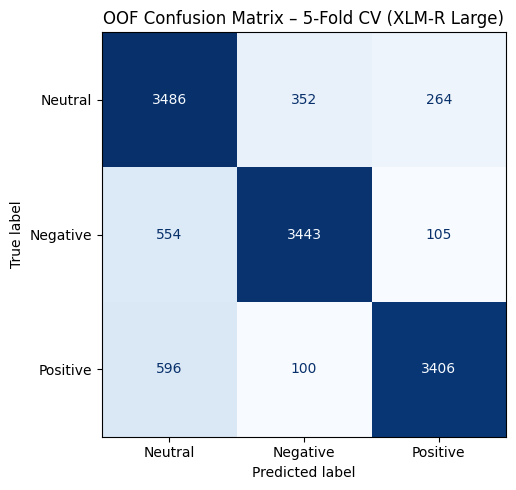

In [ ]:
# oof confusion matrix
cm   = confusion_matrix(oof_labels, oof_preds, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutral', 'Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'OOF Confusion Matrix – {N_FOLDS}-Fold CV (XLM-R Large)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cv_oof_confusion_matrix.png'), dpi=150)
plt.show()

# Error analysis

Built on the pooled out-of-fold predictions (`oof_labels`, `oof_preds`,
`oof_probs`). Every sample was predicted exactly once while it was held out,
so this is a clean, leakage-free view of *where* and *how* the model fails

It covers: overall error rate, per-class error rates, directional confusions,
the most confident mistakes (the most informative cases), confidence
calibration for correct vs. wrong predictions, error rate by text length,
and a CSV export of every misclassified sample for manual inspection.

In [ ]:
label_names = ['Neutral', 'Negative', 'Positive']   # 0, 1, 2

err_df = cv_df.copy().reset_index(drop=True)
err_df['true']       = oof_labels
err_df['pred']       = oof_preds
err_df['confidence'] = oof_probs.max(axis=1)                     # max softmax
err_df['p_true']     = oof_probs[np.arange(len(err_df)), oof_labels]  # prob assigned to the correct class
err_df['correct']    = err_df['true'] == err_df['pred']
err_df['true_name']  = [label_names[i] for i in err_df['true']]
err_df['pred_name']  = [label_names[i] for i in err_df['pred']]
err_df['text_len']   = err_df['surface'].astype(str).str.split().apply(len)  # length in words

n_total = len(err_df)
n_wrong = int((~err_df['correct']).sum())
print(f"Total samples   : {n_total}")
print(f"Misclassified   : {n_wrong}  ({100 * n_wrong / n_total:.2f}%)")
print(f"Overall accuracy: {100 * err_df['correct'].mean():.2f}%")

Total samples   : 12306
Misclassified   : 1971  (16.02%)
Overall accuracy: 83.98%


In [ ]:
# Per-class error rate + directional confusions (true -> predicted).
print("===== Per-class error rate =====")
for c, name in enumerate(label_names):
    mask  = err_df['true'] == c
    n_c   = int(mask.sum())
    err_c = int((mask & ~err_df['correct']).sum())
    print(f"  {name:9s}: {err_c:4d}/{n_c:4d} wrong  ({100 * err_c / max(n_c, 1):.2f}%)")

print("\n===== Most common confusions (true -> predicted) =====")
conf_pairs = (err_df[~err_df['correct']]
              .groupby(['true_name', 'pred_name'])
              .size()
              .sort_values(ascending=False))
for (t, p), n in conf_pairs.items():
    print(f"  {t:9s} -> {p:9s}: {n}")

===== Per-class error rate =====
  Neutral  :  616/4102 wrong  (15.02%)
  Negative :  659/4102 wrong  (16.07%)
  Positive :  696/4102 wrong  (16.97%)

===== Most common confusions (true -> predicted) =====
  Positive  -> Neutral  : 596
  Negative  -> Neutral  : 554
  Neutral   -> Negative : 352
  Neutral   -> Positive : 264
  Negative  -> Positive : 105
  Positive  -> Negative : 100


In [ ]:
# Most CONFIDENT mistakes: high confidence but wrong.
TOP_K = 20
worst = (err_df[~err_df['correct']]
         .sort_values('confidence', ascending=False)
         .head(TOP_K))

pd.set_option('display.max_colwidth', 120)
print(f"===== Top {TOP_K} most confident errors =====\n")
for _, row in worst.iterrows():
    print(f"[conf {row['confidence']:.2f}]  true={row['true_name']:9s}  pred={row['pred_name']:9s}")
    print(f"   {row['surface']}")
    print()

===== Top 20 most confident errors =====

[conf 1.00]  true=Positive   pred=Negative 
   ترسی سەرهەڵدانی توندوتیژی ڕەگەزپەرستی لە بەریتانیا لە ئارادایه بەداخەوە.

[conf 1.00]  true=Positive   pred=Negative 
   مەحمود مەشهەدانی: بە سیاسەتکردنی ڕاگەیاندن لە نهخۆش ی شێرپەنجه خراپتره.

[conf 1.00]  true=Negative   pred=Positive 
   ئەوەی خۆش ە کەس حیسابت لۆ ناکات نە کور نە عەرەب.

[conf 1.00]  true=Negative   pred=Positive 
   مەگەر بەس تۆ ئەونەی شەیتان خۆش تبوێم.

[conf 1.00]  true=Positive   pred=Negative 
   قوباد تاڵەبانی نەخۆش ی کرۆنا خەتای یەکێتی و پارتی نیە بەڵکو نە خۆش یەکی جیهانیە.

[conf 1.00]  true=Negative   pred=Positive 
   ئەمڕۆ حاجی ئۆمەران وەک خاڵێکی سنووریی فەرمی دەکرێتەوه هەواڵێکی خۆش ە.

[conf 1.00]  true=Negative   pred=Positive 
   فیلمی ژانی گەل خەڵاتی باش ترین موزیکی لە چەژنی ماڵی سینەمای ئێران بەدەست هێنا.

[conf 1.00]  true=Neutral    pred=Negative 
   پاکستان..له ئاکامی تەقینەوەیەکی خۆکوژی زیاتر لە کەس گیانیان لە دەستدا.

[conf 1.00]  true=Positive   pred=Negativ

In [ ]:
# Error rate by text length (word count).
bins       = [0, 5, 10, 20, 40, np.inf]
bucket_lbl = ['1-5', '6-10', '11-20', '21-40', '40+']
err_df['len_bucket'] = pd.cut(err_df['text_len'], bins=bins, labels=bucket_lbl)

by_len = err_df.groupby('len_bucket', observed=True).agg(
    n=('correct', 'size'),
    err_rate_pct=('correct', lambda s: 100 * (1 - s.mean())),
    mean_conf=('confidence', 'mean'),
)
print("===== Error rate by text length (words) =====")
print(by_len.round(2))

===== Error rate by text length (words) =====
               n  err_rate_pct  mean_conf
len_bucket                               
1-5         2340         12.18       0.94
6-10        6625         17.37       0.91
11-20       3063         17.04       0.91
21-40        244          5.33       0.97
40+           34          0.00       0.99


In [ ]:
# Error rate per CATEGORY (art / social / news / health / technology).
if 'category' in err_df.columns:
    by_cat = (err_df.groupby('category', observed=True)
              .agg(n=('correct', 'size'),
                   err_rate_pct=('correct', lambda s: 100 * (1 - s.mean())),
                   mean_conf=('confidence', 'mean'))
              .sort_values('err_rate_pct', ascending=False))
    print("===== Error rate by category =====")
    print(by_cat.round(2))

    # Which sentiment is confused with which, per category
    print("\n===== Confusions per category (true -> pred) =====")
    for cat, sub in err_df[~err_df['correct']].groupby('category', observed=True):
        pairs = sub.groupby(['true_name', 'pred_name']).size().sort_values(ascending=False)
        top = "; ".join(f"{t}->{p}:{n}" for (t, p), n in pairs.head(3).items())
        print(f"  {cat:11s} ({len(sub)} errors): {top}")
else:
    print("No 'category' column in cv_df — skipping the per-category breakdown.")
    print("The notebook loads KurdiSent_preprocessed.csv; if you want this section,")
    print("make sure the preprocessing in kusa_sarf_final keeps the 'category' column.")

===== Error rate by category =====
               n  err_rate_pct  mean_conf
category                                 
news        4302         23.57       0.88
technology   158         18.99       0.92
art         1759         15.29       0.92
health       624         12.82       0.95
social      5463         10.58       0.94

===== Confusions per category (true -> pred) =====
  art         (269 errors): Positive->Neutral:96; Negative->Neutral:70; Neutral->Positive:42
  health      (80 errors): Neutral->Negative:17; Positive->Neutral:16; Positive->Negative:15
  news        (1014 errors): Negative->Neutral:335; Positive->Neutral:315; Neutral->Negative:200
  social      (578 errors): Positive->Neutral:166; Negative->Neutral:124; Neutral->Positive:108
  technology  (30 errors): Negative->Neutral:11; Neutral->Positive:8; Negative->Positive:4


In [ ]:
# export misclassified samples
mis_cols = ['surface']
if 'category' in err_df.columns:
    mis_cols.append('category')
mis_cols += ['true_name', 'pred_name', 'confidence', 'p_true', 'text_len']
mis_df = (err_df.loc[~err_df['correct'], mis_cols]
          .sort_values('confidence', ascending=False)
          .reset_index(drop=True))

mis_path = os.path.join(SAVE_DIR, f"{NOTEBOOK_NAME}_misclassified.csv")
mis_df.to_csv(mis_path, index=False, encoding='utf-8')
print(f"Saved {len(mis_df)} misclassified samples to: {mis_path}")
mis_df.head(15)

Saved 1971 misclassified samples to: /content/drive/MyDrive/google_colab/kusa/kusa_baseline_cv_inc_error_analysis_alternative/kusa_baseline_cv_inc_error_analysis_alternative_misclassified.csv


,surface,category,true_name,pred_name,confidence,p_true,text_len
0,ترسی سەرهەڵدانی توندوتیژی ڕەگەزپەرستی لە بەریتانیا لە ئارادایه بەداخەوە.,news,Positive,Negative,0.999811,0.000108,9
1,مەحمود مەشهەدانی: بە سیاسەتکردنی ڕاگەیاندن لە نهخۆش ی شێرپەنجه خراپتره.,social,Positive,Negative,0.999748,0.000092,10
2,ئەوەی خۆش ە کەس حیسابت لۆ ناکات نە کور نە عەرەب.,social,Negative,Positive,0.999559,0.000359,11
3,مەگەر بەس تۆ ئەونەی شەیتان خۆش تبوێم.,social,Negative,Positive,0.999554,0.000358,7
4,قوباد تاڵەبانی نەخۆش ی کرۆنا خەتای یەکێتی و پارتی نیە بەڵکو نە خۆش یەکی جیهانیە.,health,Positive,Negative,0.999554,0.000244,15
5,ئەمڕۆ حاجی ئۆمەران وەک خاڵێکی سنووریی فەرمی دەکرێتەوه هەواڵێکی خۆش ە.,news,Negative,Positive,0.999550,0.000258,11
6,فیلمی ژانی گەل خەڵاتی باش ترین موزیکی لە چەژنی ماڵی سینەمای ئێران بەدەست هێنا.,social,Negative,Positive,0.999529,0.000250,14
7,پاکستان..له ئاکامی تەقینەوەیەکی خۆکوژی زیاتر لە کەس گیانیان لە دەستدا.,news,Neutral,Negative,0.999503,0.000444,10
8,هەولێر .. لە سەر ڕەفز وەرگرتن کوڕێک هەڕەشەی کوشتنی لە کچێک کرد.,news,Positive,Negative,0.999501,0.000140,12
9,چین..سەد و پێنج کرێکار گیانیان لە دەستدا.,art,Neutral,Negative,0.999495,0.000399,7
